In [1]:
import cv2
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
import os
from sklearn.model_selection import train_test_split
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import time

In [2]:
os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo reimplement")
from classes.CNN_pytorch_copy import YOLO, CNN_model, YoloDataset, YoloLoss, YOLOVisualizer #import my class CNN

In [3]:
os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo reimplement\data\Pascal_VOC\train")

path = r"C:\Users\Lucas\Desktop\vacantion classes\Yolo reimplement\data\Pascal_VOC\train"

xml_list = []
for filename in os.listdir(path):
    if not filename.endswith('.xml'): continue
    fullname = os.path.join(path, filename)
    xml_list.append(fullname)

my_CNN = CNN_model()
my_CNN.get_annotation(xml_list)
my_CNN.encode_pictures()

In [4]:
os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo reimplement")
my_CNN.df.to_json(r"data\annot_df.json",orient="records")
torch.save(my_CNN.encoded_picture_annot, r"data\encoded_picture.pt")

In [3]:
my_classes = ['aeroplane','person','boat','bird','tvmonitor','sheep','diningtable','bottle','horse','train','motorbike','sofa','chair','cow',
 'bicycle','car','cat','bus','pottedplant','dog']

In [4]:
os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo reimplement")
df_encoded = torch.load(r"data\encoded_picture.pt",weights_only=False)
df_encoded

,file_name,encoded_grid
1,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
2,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
3,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
4,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
5,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
...,...,...
13295,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
13296,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
13297,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
13298,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."


In [5]:
X_train, X_test, y_train, y_test = train_test_split(df_encoded['file_name'],df_encoded['encoded_grid'],test_size=0.4, random_state=42)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [6]:
X_train = X_train[:4000]
y_train = y_train[:4000]

In [7]:
train_dataset = YoloDataset(X_train, y_train)
test_dataset = YoloDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [8]:
def show_yolo_label(img_tensor, label_tensor, img_size=448, conf_threshold=0.5, S=7):
    # Convert tensor to numpy and back to OpenCV format (HWC)
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img * 255).astype('uint8')
    img = img[..., ::-1].copy()  # RGB -> BGR for OpenCV

    # Draw YOLO grid
    step = img_size // S
    for i in range(1, S):
        # horizontal line
        cv2.line(img, (0, i*step), (img_size, i*step), color=(255, 255, 255), thickness=1)
        # vertical line
        cv2.line(img, (i*step, 0), (i*step, img_size), color=(255, 255, 255), thickness=1)

    # Draw bounding boxes
    if label_tensor.ndim == 3:
        for i in range(S):
            for j in range(S):
                cell = label_tensor[i, j]
                if cell[0] > conf_threshold:  # confidence score
                    x, y, w, h = cell[1:5]
                    # Convert to absolute coords
                    x_center = (j + x) / S * img_size
                    y_center = (i + y) / S * img_size
                    w_pixel = w * img_size
                    h_pixel = h * img_size
                    x1 = int(x_center - w_pixel / 2)
                    y1 = int(y_center - h_pixel / 2)
                    x2 = int(x_center + w_pixel / 2)
                    y2 = int(y_center + h_pixel / 2)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    else:
        boxes = label_tensor.view(-1, 5 if label_tensor.shape[-1] == 5 else 4)
        for box in boxes:
            if box.numel() == 5:
                _, x, y, w, h = box
            else:
                x, y, w, h = box
            x1 = int((x - w/2) * img_size)
            y1 = int((y - h/2) * img_size)
            x2 = int((x + w/2) * img_size)
            y2 = int((y + h/2) * img_size)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # Show image
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


c:\Users\Lucas\Desktop\vacantion classes\Yolo reimplement\classes\CNN_pytorch_copy.py:308: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(self.Y_tensor[idx], dtype=torch.float32)


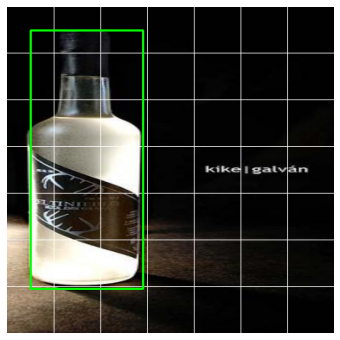

In [9]:
img, label = train_dataset[0]
show_yolo_label(img, label)

In [10]:
def compare_pred_vs_true( img_tensor, pred_tensor, target_tensor, img_size=448, conf_threshold=0.3):
    """
    Visualize both predicted and ground truth boxes on the same image.
    Predicted boxes: green
    Ground truth boxes: red
    """

    # Convert tensor to numpy image
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * 255).astype('uint8')
    img = img[..., ::-1].copy()  # RGB -> BGR for OpenCV

    S = 7
    step = img_size // S

    for i in range(S):
        for j in range(S):
            # === Ground truth ===
            tcell = target_tensor[i, j]
            if tcell[0] > 0:  # object present
                tx, ty, tw, th = tcell[1:5]
                x_center = (j + tx) / S * img_size
                y_center = (i + ty) / S * img_size
                w_pixel = tw * img_size
                h_pixel = th * img_size
                x1 = int(x_center - w_pixel / 2)
                y1 = int(y_center - h_pixel / 2)
                x2 = int(x_center + w_pixel / 2)
                y2 = int(y_center + h_pixel / 2)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)  # RED = ground truth

            # === Prediction ===
            pcell = pred_tensor[i, j]
            for b in range(1):
                conf = torch.sigmoid(torch.tensor(pcell[0])).item()
                if conf < conf_threshold:
                    continue
                x, y, w, h = pcell[b*5+1:b*5+5]
                x_center = (j + x) / S * img_size
                y_center = (i + y) / S * img_size
                w_pixel = abs(w) * img_size
                h_pixel = abs(h) * img_size
                x1 = int(x_center - w_pixel / 2)
                y1 = int(y_center - h_pixel / 2)
                x2 = int(x_center + w_pixel / 2)
                y2 = int(y_center + h_pixel / 2)
                x1 = max(0, min(x1, img.shape[1] - 1))
                x2 = max(0, min(x2, img.shape[1] - 1))
                y1 = max(0, min(y1, img.shape[0] - 1))
                y2 = max(0, min(y2, img.shape[0] - 1))
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)  # GREEN = prediction

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("YOLO — Predicted (green) vs Ground Truth (red)")
    plt.axis('off')
    plt.show()

## Training

In [11]:
def generate_anchors(scales, ratios):
    """Generates anchor boxes for given scales and aspect ratios."""
    anchors = []
    for scale in scales:
        for ratio in ratios:
            width = scale * np.sqrt(ratio)
            height = scale / np.sqrt(ratio)
            anchors.append((width, height))
    return np.array(anchors)

# Example: Scales and ratios
scales = [0.1, 0.2, 0.4]
ratios = [0.5, 1, 2]
anchors = generate_anchors(scales, ratios)
print("Anchor Boxes:", anchors)

Anchor Boxes: [[0.07071068 0.14142136]
 [0.1        0.1       ]
 [0.14142136 0.07071068]
 [0.14142136 0.28284271]
 [0.2        0.2       ]
 [0.28284271 0.14142136]
 [0.28284271 0.56568542]
 [0.4        0.4       ]
 [0.56568542 0.28284271]]


In [14]:
def yolo_loss(predictions, targets, num_classes=20, lambda_coord=5, lambda_noobj=0.5):
    """
    Computes YOLO loss.
    - predictions: Predicted tensor.
    - targets: Ground truth tensor.
    """
    # Unpack predictions and targets
    pred_boxes = predictions[..., 1:5]
    pred_conf = predictions[..., 0]
    pred_classes = predictions[..., 5:]
    target_boxes = targets[..., 1:5]
    target_conf = targets[..., 0]
    target_classes = targets[..., 5:]
    
    # Localization Loss
    box_loss = lambda_coord * torch.sum((pred_boxes - target_boxes) ** 2)

    # Confidence Loss
    obj_loss = torch.sum((pred_conf - target_conf) ** 2)
    noobj_loss = lambda_noobj * torch.sum((pred_conf[target_conf == 0]) ** 2)

    # Classification Loss
    class_loss = torch.sum((pred_classes - target_classes) ** 2)

    # Total Loss
    total_loss = box_loss + obj_loss + noobj_loss + class_loss
    return total_loss/len(train_dataset)

In [13]:
#model = torch.hub.load('ultralytics/yolov3', 'yolov3', pretrained=True)
#torch.save(model.state_dict(), 'yolov3_coco_pretrained.pth')


In [15]:
def load_pretrained_weights(model, weight_path):
    """Loads pre-trained weights into the YOLO model."""
    state_dict = torch.load(weight_path)
    model.load_state_dict(state_dict, strict=False)  # strict=False allows partial loading
    print("Pre-trained weights loaded successfully!")
    return model

# Example usage
#weight_path = "yolov3_coco_pretrained.pth"
#model = YOLO(grid_size=7, num_classes=20, num_anchors=3)
#model = load_pretrained_weights(model, weight_path)

epoch  0


C:\Users\Lucas\AppData\Local\Temp\ipykernel_6232\1182715856.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  conf = torch.sigmoid(torch.tensor(pcell[0])).item()


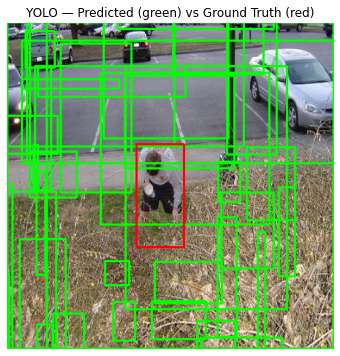

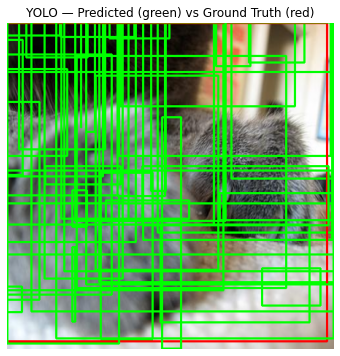

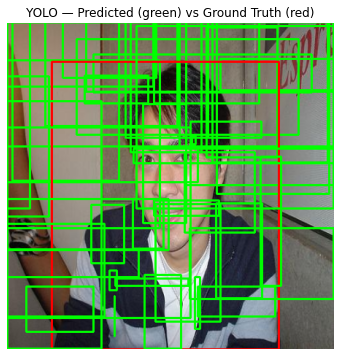

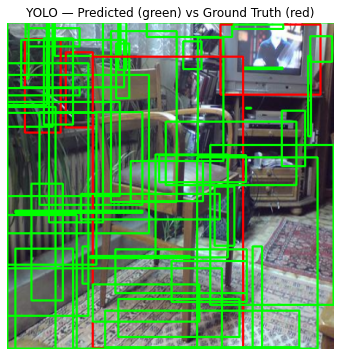

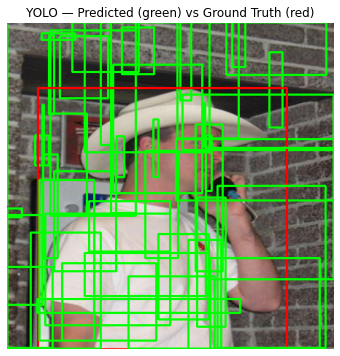

estimated time for training = 7808.286781311035
Epoch 1/80, Loss: 22.5173
epoch  1
Epoch 2/80, Loss: 14.3616
epoch  2
Epoch 3/80, Loss: 13.7592
epoch  3
Epoch 4/80, Loss: 13.3053
epoch  4
Epoch 5/80, Loss: 12.9558
epoch  5
Epoch 6/80, Loss: 12.9482
epoch  6
Epoch 7/80, Loss: 13.3119
epoch  7
Epoch 8/80, Loss: 12.9569
epoch  8
Epoch 9/80, Loss: 12.7825
epoch  9
Epoch 10/80, Loss: 12.2421
epoch  10
Epoch 11/80, Loss: 12.2136
epoch  11
Epoch 12/80, Loss: 11.9021
epoch  12
Epoch 13/80, Loss: 11.7772
epoch  13
Epoch 14/80, Loss: 11.4846
epoch  14
Epoch 15/80, Loss: 11.2061
epoch  15


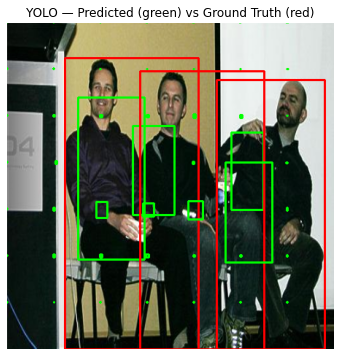

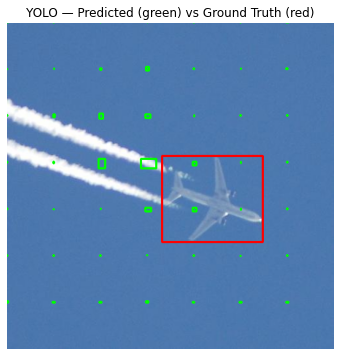

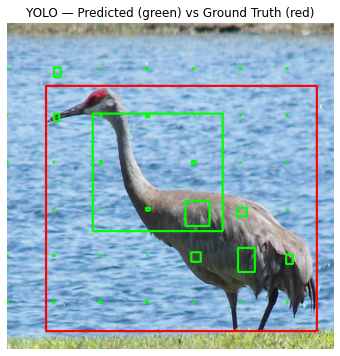

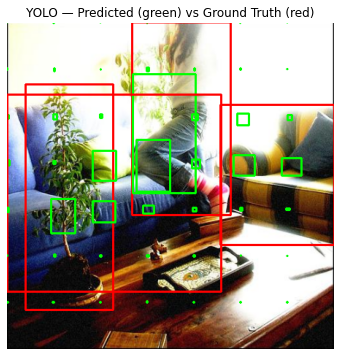

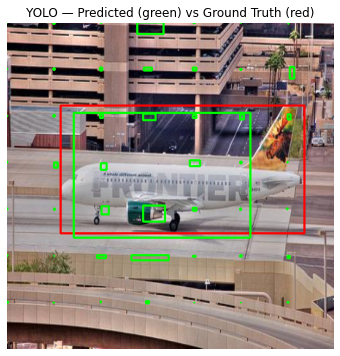

Epoch 16/80, Loss: 11.0901
epoch  16
Epoch 17/80, Loss: 11.7886
epoch  17
Epoch 18/80, Loss: 12.7767
epoch  18
Epoch 19/80, Loss: 11.1543
epoch  19
Epoch 20/80, Loss: 10.4064
epoch  20
Epoch 21/80, Loss: 10.2050
epoch  21
Epoch 22/80, Loss: 9.6433
epoch  22
Epoch 23/80, Loss: 9.4894
epoch  23
Epoch 24/80, Loss: 9.1341
epoch  24
Epoch 25/80, Loss: 9.1756
epoch  25
Epoch 26/80, Loss: 8.7393
epoch  26
Epoch 27/80, Loss: 8.4159
epoch  27
Epoch 28/80, Loss: 8.3103
epoch  28
Epoch 29/80, Loss: 8.2150
epoch  29
Epoch 30/80, Loss: 7.9739
epoch  30


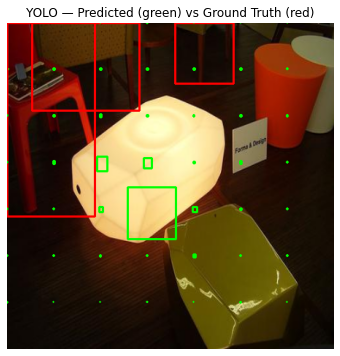

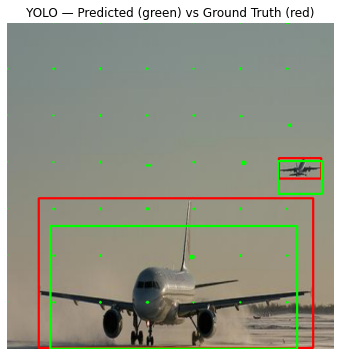

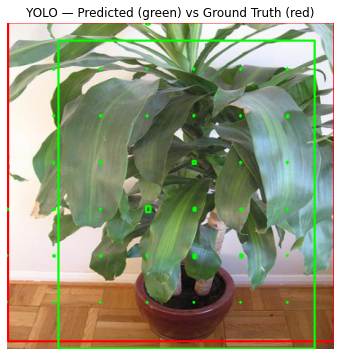

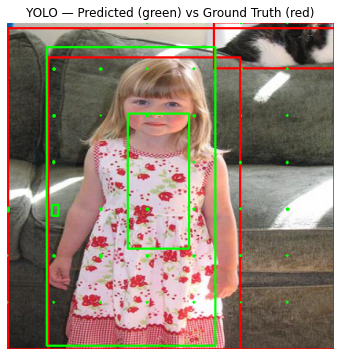

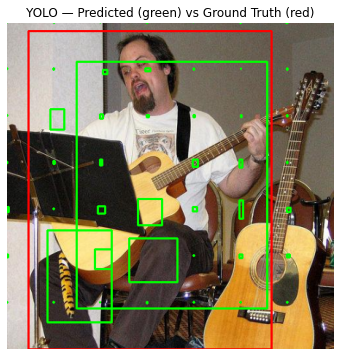

Epoch 31/80, Loss: 7.6909
epoch  31
Epoch 32/80, Loss: 7.5471
epoch  32
Epoch 33/80, Loss: 7.4505
epoch  33
Epoch 34/80, Loss: 7.1860
epoch  34
Epoch 35/80, Loss: 7.0472
epoch  35
Epoch 36/80, Loss: 6.8578
epoch  36
Epoch 37/80, Loss: 6.7662
epoch  37
Epoch 38/80, Loss: 6.5159
epoch  38
Epoch 39/80, Loss: 6.5453
epoch  39
Epoch 40/80, Loss: 6.3763
epoch  40
Epoch 41/80, Loss: 6.2751
epoch  41
Epoch 42/80, Loss: 6.2048
epoch  42
Epoch 43/80, Loss: 6.1412
epoch  43
Epoch 44/80, Loss: 5.8638
epoch  44
Epoch 45/80, Loss: 6.0868
epoch  45


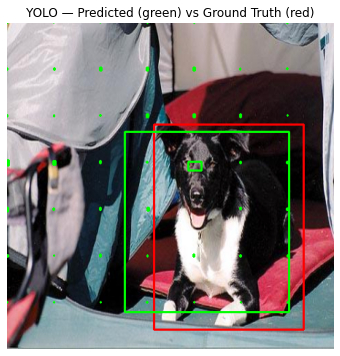

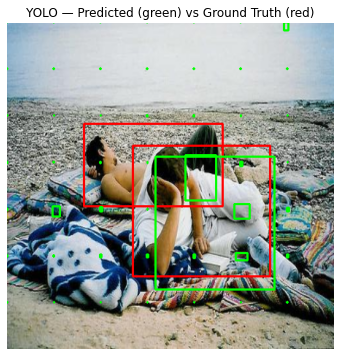

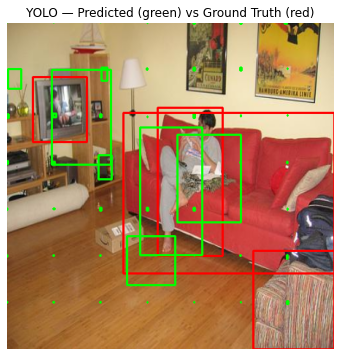

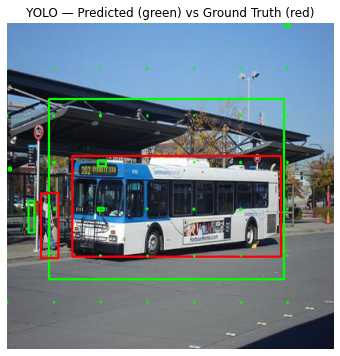

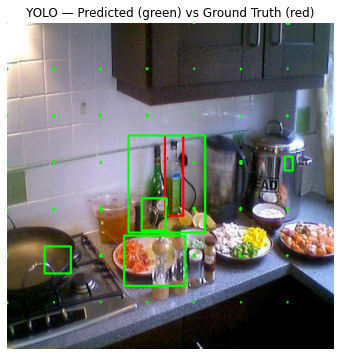

Epoch 46/80, Loss: 5.7428
epoch  46
Epoch 47/80, Loss: 5.5715
epoch  47
Epoch 48/80, Loss: 5.6761
epoch  48
Epoch 49/80, Loss: 5.3936
epoch  49
Epoch 50/80, Loss: 5.2428
epoch  50
Epoch 51/80, Loss: 5.2648
epoch  51
Epoch 52/80, Loss: 5.3230
epoch  52
Epoch 53/80, Loss: 5.1298
epoch  53
Epoch 54/80, Loss: 5.2157
epoch  54
Epoch 55/80, Loss: 4.9344
epoch  55
Epoch 56/80, Loss: 4.8291
epoch  56
Epoch 57/80, Loss: 4.7405
epoch  57
Epoch 58/80, Loss: 4.8078
epoch  58
Epoch 59/80, Loss: 4.7984
epoch  59
Epoch 60/80, Loss: 4.5901
epoch  60


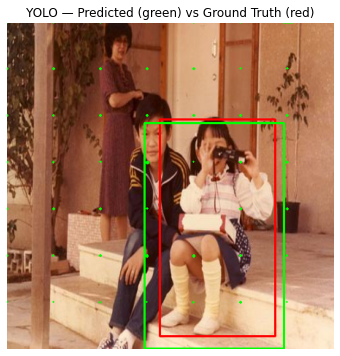

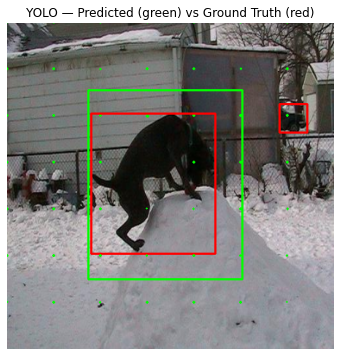

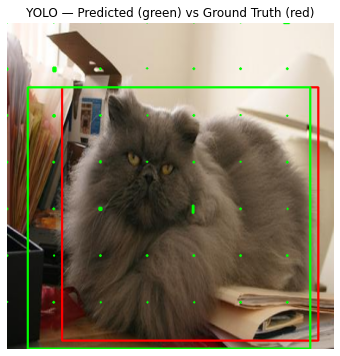

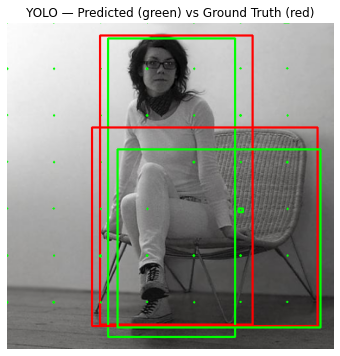

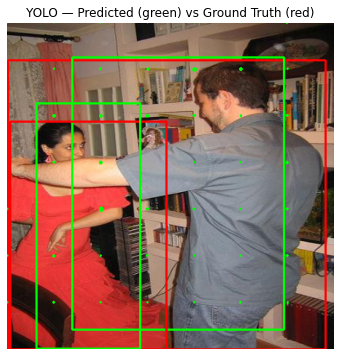

Epoch 61/80, Loss: 4.4147
epoch  61
Epoch 62/80, Loss: 4.4011
epoch  62
Epoch 63/80, Loss: 4.3486
epoch  63
Epoch 64/80, Loss: 4.4319
epoch  64
Epoch 65/80, Loss: 4.4612
epoch  65
Epoch 66/80, Loss: 4.1749
epoch  66
Epoch 67/80, Loss: 4.1446
epoch  67
Epoch 68/80, Loss: 3.9188
epoch  68
Epoch 69/80, Loss: 4.1020
epoch  69
Epoch 70/80, Loss: 4.0268
epoch  70
Epoch 71/80, Loss: 3.9726
epoch  71
Epoch 72/80, Loss: 3.8748
epoch  72
Epoch 73/80, Loss: 3.8381
epoch  73
Epoch 74/80, Loss: 3.8685
epoch  74
Epoch 75/80, Loss: 3.6880
epoch  75


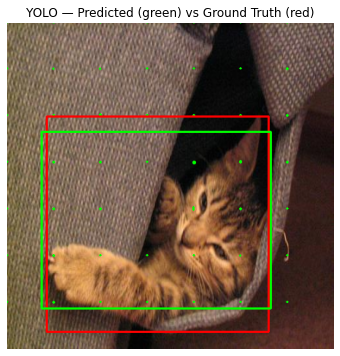

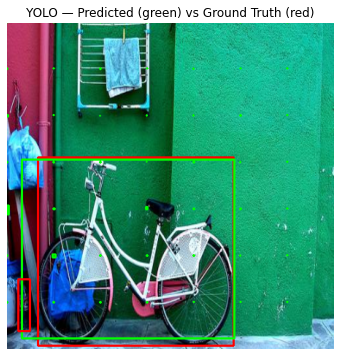

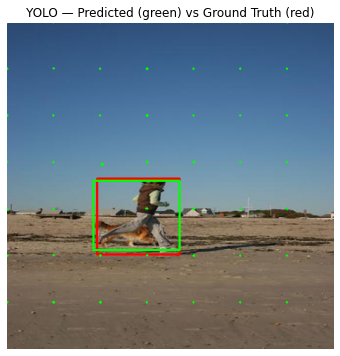

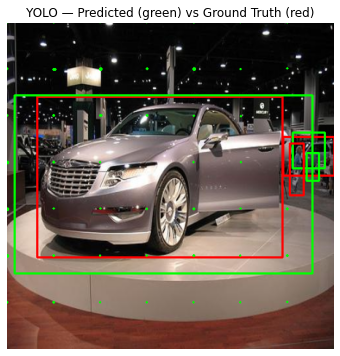

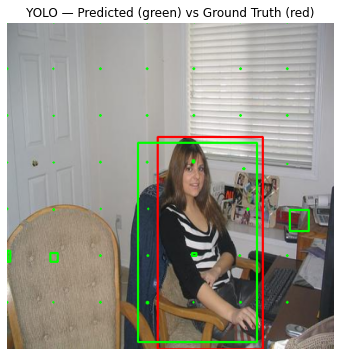

Epoch 76/80, Loss: 3.6936
epoch  76
Epoch 77/80, Loss: 3.8031
epoch  77
Epoch 78/80, Loss: 3.6711
epoch  78
Epoch 79/80, Loss: 3.4727
epoch  79
Epoch 80/80, Loss: 3.3096
model saved


In [17]:
import torch.optim as optim

# Initialize model, optimizer, and loss function
model = YOLO(grid_size=7, num_classes=20, num_anchors=1).to('cuda')
optimizer = optim.Adam(model.parameters(), lr=0.001)
#optimizer = torch.optim.SGD(model.parameters(),lr=0.001,momentum=0.9,weight_decay=5e-4)

#criterion = yolo_loss  # Your loss function from earlier
criterion = YoloLoss(S=7, B=2, C=20, l_obj=15, l_nobj=0.5)
# Training loop
num_epochs = 80
estimated_time = 0
for epoch in range(num_epochs):
    print("epoch ", epoch)
    if epoch == 0:
        start_time = time.time()
    model.train()
    epoch_loss = 0
    print_count = 0
    for images, targets in train_loader:
        images = images.to('cuda')  # Move to GPU if available
        targets = targets.to('cuda')
        # Forward pass
        predictions = model(images)
        if epoch % 15 == 0 and print_count < 5:
            compare_pred_vs_true(images[0],pred_tensor=predictions[0],target_tensor=targets[0])
            print_count += 1
        # Loss calculation
        #loss = criterion(predictions, targets, num_classes=20)
        loss = yolo_loss(predictions, targets)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    if epoch == 0:
        print("estimated time for training =", num_epochs*(time.time()-start_time))
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")


torch.save(model.state_dict(), "yolo_weights3.pth")
print("model saved")

In [18]:
model = YOLO(grid_size=7, num_classes=20, num_anchors=1).to('cuda')
model.load_state_dict(torch.load("yolo_weights3.pth"))
model.eval()

YOLO(
  (backbone): YOLOBackbone(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_size=(1, 1),

tensor([[[0.8353, 0.8392, 0.8392,  ..., 0.8510, 0.8510, 0.8510],
         [0.8392, 0.8392, 0.8431,  ..., 0.8510, 0.8510, 0.8510],
         [0.8471, 0.8471, 0.8431,  ..., 0.8510, 0.8510, 0.8510],
         ...,
         [0.8784, 0.8784, 0.8784,  ..., 0.8784, 0.8784, 0.8784],
         [0.8784, 0.8784, 0.8784,  ..., 0.8784, 0.8784, 0.8784],
         [0.8784, 0.8784, 0.8784,  ..., 0.8784, 0.8784, 0.8784]],

        [[0.8706, 0.8745, 0.8745,  ..., 0.8863, 0.8863, 0.8863],
         [0.8745, 0.8745, 0.8784,  ..., 0.8863, 0.8863, 0.8863],
         [0.8824, 0.8824, 0.8784,  ..., 0.8863, 0.8863, 0.8863],
         ...,
         [0.9255, 0.9255, 0.9255,  ..., 0.9255, 0.9255, 0.9255],
         [0.9255, 0.9255, 0.9255,  ..., 0.9255, 0.9255, 0.9255],
         [0.9255, 0.9255, 0.9255,  ..., 0.9255, 0.9255, 0.9255]],

        [[0.8667, 0.8706, 0.8706,  ..., 0.8745, 0.8745, 0.8745],
         [0.8706, 0.8706, 0.8745,  ..., 0.8745, 0.8745, 0.8745],
         [0.8784, 0.8784, 0.8745,  ..., 0.8745, 0.8745, 0.

C:\Users\Lucas\AppData\Local\Temp\ipykernel_6232\1182715856.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  conf = torch.sigmoid(torch.tensor(pcell[0])).item()


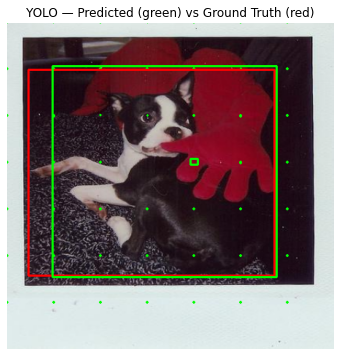

In [19]:
img = test_dataset[822][0]
img = img.to('cuda')
print(img)
target = test_dataset[822][1]
pred = model(img.unsqueeze(0))
compare_pred_vs_true(img,pred[0],target)

In [26]:
x_path = "WhatsApp Image 2025-11-14 at 08.26.06_1fae25c9.jpg"
x_path = "download.jpg"
x_path = "photo-1526779259212-939e64788e3c.jpg"
x_path = "photo-1526779259212-939e64788e3c.jpg"
x_path = "shit-image-4300034_1280.jpg"
x_path = "download.jpg"
x_path = "WhatsApp Image 2025-11-14 at 08.26.06_1fae25c9.jpg"

img = cv2.imread(x_path)
img = cv2.resize(img, (448, 448))
img = img[..., ::-1]  # BGR to RGB
img = img / 255.0
img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)  # (C,H,W)

In [27]:
img = img.to('cuda')
pred = model(img.unsqueeze(0))
pred = pred.to('cuda')

In [22]:
pred[0][4]

tensor([[ 5.3565e-03,  2.4676e-03,  3.4457e-03,  1.5040e-03,  3.0535e-03,
         -7.3920e-05,  2.4141e-03,  8.7525e-04,  1.7320e-03,  6.9530e-05,
          4.0434e-04,  1.6213e-03,  1.0855e-03, -7.7378e-04,  6.1037e-04,
         -7.2490e-05,  3.3121e-04,  1.9793e-03, -1.6563e-03,  3.2712e-04,
         -6.6708e-04,  1.0550e-04, -6.4076e-05,  5.5290e-04,  9.0118e-04],
        [ 3.4710e-03,  1.2449e-03,  2.0866e-03,  8.8650e-04,  2.2271e-03,
         -8.6292e-05,  1.6188e-03,  8.7477e-04,  1.7119e-03, -9.7824e-05,
          3.6737e-04,  1.5223e-03,  7.4390e-04, -8.0881e-04,  5.3135e-04,
         -1.4310e-04,  1.8557e-04,  1.6378e-03, -1.7330e-03,  2.8005e-04,
         -7.8615e-04, -4.9233e-06, -1.3579e-05,  2.2255e-04,  8.9961e-04],
        [ 1.5657e-03,  2.4319e-05,  9.7639e-04,  1.3484e-04,  1.2375e-03,
         -5.3077e-05,  8.6336e-04,  8.8267e-04,  1.6607e-03, -2.3801e-04,
          3.4973e-04,  1.4483e-03,  2.4030e-04, -7.7808e-04,  4.4881e-04,
         -3.0142e-04, -4.8130e-05,  

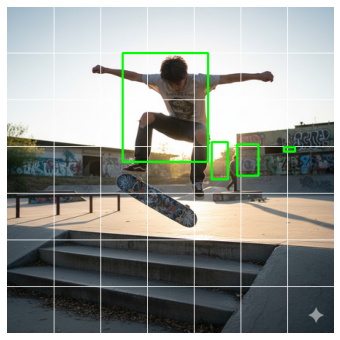

In [29]:
show_yolo_label(img.cpu(),label_tensor=pred[0],conf_threshold=0.1)

In [64]:
visualizer = YOLOVisualizer(S=7,B=2,C=20,classes=my_classes,score_threshold=0.00001)
visualizer.visualize_single(model,img_path=x_path,device='cuda')